In [1]:
!pip -q install datasets sacrebleu gensim nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.1 MB/s eta 0:00:00


In [2]:
import os
import re
import math
import json
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
import gensim.downloader as api
import nltk
from nltk.tokenize import word_tokenize
import sacrebleu

nltk.download("punkt")
nltk.download("punkt_tab", quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Using device: cuda


In [37]:
CONFIG = {
    "text_gen": {
        "seq_len": 20,
        "batch_size": 128,
        "hidden_dim": 256,
        "num_layers": 2,
        "dropout": 0.3,
        "embed_dim": 100,
        "epochs": 5,
        "lr": 1e-3,
        "max_vocab": 8000,
        "generate_len": 25
    },
    "translation": {
        "batch_size": 64,
        "hidden_dim": 256,
        "num_layers": 1,
        "dropout": 0.2,
        "embed_dim": 100,
        "epochs": 8,
        "lr": 1e-3,
        "max_src_vocab": 10000,
        "max_tgt_vocab": 10000,
        "max_len": 20,
        "teacher_forcing": 0.7,
        "train_size": 20000,
        "val_size": 2000,
        "test_size": 2000
    }
}

In [4]:
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s.,;:!?'-]", " ", text)
    return word_tokenize(text)

tokens = simple_tokenize(text)
print("Total tokens:", len(tokens))
print(tokens[:40])

Total tokens: 254764
['first', 'citizen', ':', 'before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'all', ':', 'speak', ',', 'speak', '.', 'first', 'citizen', ':', 'you', 'are', 'all', 'resolved', 'rather', 'to', 'die', 'than', 'to', 'famish', '?', 'all', ':', 'resolved', '.', 'resolved', '.', 'first']


In [5]:
SPECIALS = ["<pad>", "<unk>"]

def build_vocab(tokens, max_vocab=8000):
    counter = Counter(tokens)
    most_common = counter.most_common(max_vocab - len(SPECIALS))
    itos = SPECIALS + [w for w, _ in most_common]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos

stoi_tg, itos_tg = build_vocab(tokens, CONFIG["text_gen"]["max_vocab"])
vocab_size_tg = len(itos_tg)

def encode_tokens(tokens, stoi):
    return [stoi.get(tok, stoi["<unk>"]) for tok in tokens]

encoded_tg = encode_tokens(tokens, stoi_tg)

split1 = int(0.8 * len(encoded_tg))
split2 = int(0.9 * len(encoded_tg))

train_ids_tg = encoded_tg[:split1]
val_ids_tg = encoded_tg[split1:split2]
test_ids_tg = encoded_tg[split2:]

class TextGenDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len

    def __len__(self):
        return len(self.ids) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx: idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx + self.seq_len], dtype=torch.long)
        return x, y

seq_len = CONFIG["text_gen"]["seq_len"]

train_ds_tg = TextGenDataset(train_ids_tg, seq_len)
val_ds_tg = TextGenDataset(val_ids_tg, seq_len)
test_ds_tg = TextGenDataset(test_ids_tg, seq_len)

train_loader_tg = DataLoader(train_ds_tg, batch_size=CONFIG["text_gen"]["batch_size"], shuffle=True)
val_loader_tg = DataLoader(val_ds_tg, batch_size=CONFIG["text_gen"]["batch_size"])
test_loader_tg = DataLoader(test_ds_tg, batch_size=CONFIG["text_gen"]["batch_size"])

print("Vocabulary size:", vocab_size_tg)
print("Train samples:", len(train_ds_tg))
print("Val samples:", len(val_ds_tg))
print("Test samples:", len(test_ds_tg))

Vocabulary size: 8000
Train samples: 203791
Val samples: 25456
Test samples: 25457


In [6]:
glove = api.load("glove-wiki-gigaword-100")

def build_glove_matrix(itos, glove_model, embed_dim=100):
    matrix = np.random.normal(scale=0.6, size=(len(itos), embed_dim)).astype(np.float32)
    matrix[0] = np.zeros(embed_dim, dtype=np.float32)  # <pad>
    found = 0
    for i, word in enumerate(itos):
        if word in glove_model:
            matrix[i] = glove_model[word]
            found += 1
    print(f"GloVe found for {found}/{len(itos)} tokens")
    return torch.tensor(matrix, dtype=torch.float32)

glove_matrix_tg = build_glove_matrix(
    itos_tg,
    glove,
    embed_dim=CONFIG["text_gen"]["embed_dim"]
)

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe found for 7071/8000 tokens


In [7]:
class TextGenLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_layers, dropout,
                 embedding_type="onehot", embed_dim=100, pretrained_matrix=None):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_type = embedding_type

        if embedding_type == "glove":
            self.embedding = nn.Embedding(vocab_size, embed_dim)
            if pretrained_matrix is not None:
                self.embedding.weight.data.copy_(pretrained_matrix)
            input_dim = embed_dim
        else:
            self.embedding = None
            input_dim = vocab_size

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        if self.embedding_type == "glove":
            x = self.embedding(x)
        else:
            x = F.one_hot(x, num_classes=self.vocab_size).float()

        out, _ = self.lstm(x)
        out = out[:, -1, :]
        logits = self.fc(out)
        return logits

In [8]:
def train_epoch_textgen(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

def eval_epoch_textgen(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity

def generate_text(model, prompt, stoi, itos, seq_len=20, generate_len=25):
    model.eval()

    toks = simple_tokenize(prompt)
    ids = [stoi.get(tok, stoi["<unk>"]) for tok in toks]

    if len(ids) < seq_len:
        ids = [stoi["<pad>"]] * (seq_len - len(ids)) + ids
    else:
        ids = ids[-seq_len:]

    generated = toks[:]
    current_ids = ids[:]

    with torch.no_grad():
        for _ in range(generate_len):
            x = torch.tensor([current_ids], dtype=torch.long).to(DEVICE)
            logits = model(x)
            next_id = torch.argmax(logits, dim=-1).item()
            next_token = itos[next_id]
            generated.append(next_token)
            current_ids = current_ids[1:] + [next_id]

    return " ".join(generated)

In [15]:
textgen_results = {}

experiments_tg = [
    ("LSTM_onehot", "onehot"),
    ("LSTM_glove", "glove"),
]

for exp_name, emb_type in experiments_tg:
    print(f"\n===== Running {exp_name} =====")

    model = TextGenLSTM(
        vocab_size=vocab_size_tg,
        hidden_dim=CONFIG["text_gen"]["hidden_dim"],
        num_layers=CONFIG["text_gen"]["num_layers"],
        dropout=CONFIG["text_gen"]["dropout"],
        embedding_type=emb_type,
        embed_dim=CONFIG["text_gen"]["embed_dim"],
        pretrained_matrix=glove_matrix_tg if emb_type == "glove" else None
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=CONFIG["text_gen"]["lr"])
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_ppl": []}

    for epoch in range(CONFIG["text_gen"]["epochs"]):
        train_loss = train_epoch_textgen(model, train_loader_tg, optimizer, criterion)
        val_loss, val_ppl = eval_epoch_textgen(model, val_loader_tg, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_ppl"].append(val_ppl)

        print(
            f"Epoch {epoch+1}/{CONFIG['text_gen']['epochs']} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val PPL: {val_ppl:.2f}"
        )

    test_loss, test_ppl = eval_epoch_textgen(model, test_loader_tg, criterion)

    sample_1 = generate_text(
        model,
        "to be or not to be",
        stoi_tg,
        itos_tg,
        seq_len=CONFIG["text_gen"]["seq_len"],
        generate_len=CONFIG["text_gen"]["generate_len"]
    )
    sample_2 = generate_text(
        model,
        "the king hath",
        stoi_tg,
        itos_tg,
        seq_len=CONFIG["text_gen"]["seq_len"],
        generate_len=CONFIG["text_gen"]["generate_len"]
    )

    textgen_results[exp_name] = {
        "test_loss": test_loss,
        "test_perplexity": test_ppl,
        "samples": [sample_1, sample_2],
        "history": history
    }

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Perplexity: {test_ppl:.2f}")
    print("Sample 1:", sample_1)
    print("Sample 2:", sample_2)


===== Running LSTM_onehot =====
Epoch 1/5 | Train Loss: 6.0310 | Val Loss: 5.7122 | Val PPL: 302.54
Epoch 2/5 | Train Loss: 5.3771 | Val Loss: 5.4152 | Val PPL: 224.79
Epoch 3/5 | Train Loss: 5.3001 | Val Loss: 5.3266 | Val PPL: 205.75
Epoch 4/5 | Train Loss: 4.8934 | Val Loss: 5.2721 | Val PPL: 194.82
Epoch 5/5 | Train Loss: 4.6684 | Val Loss: 5.2964 | Val PPL: 199.62
Test Loss: 5.7696
Test Perplexity: 320.41
Sample 1: to be or not to be <unk> 'd , and <unk> 'd , and <unk> , and <unk> , and <unk> , and <unk> , and <unk> , and <unk> ,
Sample 2: the king hath been 'd , and the <unk> of the <unk> of the <unk> , and the <unk> of the <unk> of the <unk> , and <unk>

===== Running LSTM_glove =====
Epoch 1/5 | Train Loss: 5.7483 | Val Loss: 5.4261 | Val PPL: 227.27
Epoch 2/5 | Train Loss: 5.1400 | Val Loss: 5.2809 | Val PPL: 196.54
Epoch 3/5 | Train Loss: 4.9025 | Val Loss: 5.2238 | Val PPL: 185.64
Epoch 4/5 | Train Loss: 4.7169 | Val Loss: 5.2146 | Val PPL: 183.94
Epoch 5/5 | Train Loss: 4.

In [16]:
tg_rows = []
for name, res in textgen_results.items():
    tg_rows.append({
        "Experiment": name,
        "Test Loss": round(res["test_loss"], 4),
        "Test Perplexity": round(res["test_perplexity"], 2),
        "Sample Output": res["samples"][0][:120]
    })

tg_df = pd.DataFrame(tg_rows).sort_values("Test Perplexity")
tg_df

,Experiment,Test Loss,Test Perplexity,Sample Output
1,LSTM_glove,5.6891,295.61,"to be or not to be a <unk> , and <unk> , and <..."
0,LSTM_onehot,5.7696,320.41,"to be or not to be <unk> 'd , and <unk> 'd , a..."


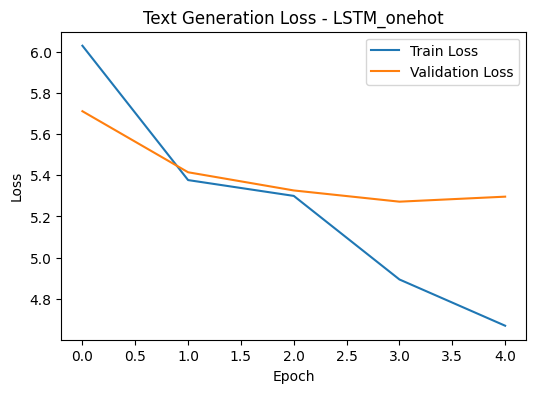

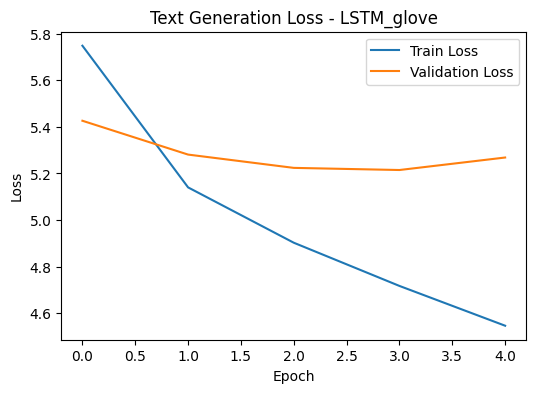

In [17]:
for name, res in textgen_results.items():
    plt.figure(figsize=(6, 4))
    plt.plot(res["history"]["train_loss"], label="Train Loss")
    plt.plot(res["history"]["val_loss"], label="Validation Loss")
    plt.title(f"Text Generation Loss - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [38]:
# PART B — MACHINE TRANSLATION
dataset = load_dataset("opus_books", "en-es")

print(dataset)

full_data = dataset["train"].shuffle(seed=SEED)

train_size = CONFIG["translation"]["train_size"]
val_size = CONFIG["translation"]["val_size"]
test_size = CONFIG["translation"]["test_size"]

train_raw = full_data.select(range(0, train_size))
val_raw = full_data.select(range(train_size, train_size + val_size))
test_raw = full_data.select(range(train_size + val_size, train_size + val_size + test_size))

print(train_raw[0])
print("Train size:", len(train_raw))
print("Val size:", len(val_raw))
print("Test size:", len(test_raw))

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 93470
    })
})
{'id': '60296', 'translation': {'en': 'Kitty, on the contrary, was more active than usual and even more animated.', 'es': 'Kitty, al contrario, estaba más activa a incluso más animada que nunca.'}}
Train size: 20000
Val size: 2000
Test size: 2000


In [39]:
SPECIALS_MT = ["<pad>", "<unk>", "<sos>", "<eos>"]

def tokenize_en(text):
    return word_tokenize(text.lower().strip())

def tokenize_es(text):
    return word_tokenize(text.lower().strip())

def build_vocab_mt(sentences, tokenizer, max_vocab):
    counter = Counter()
    for sent in sentences:
        counter.update(tokenizer(sent))
    most_common = counter.most_common(max_vocab - len(SPECIALS_MT))
    itos = SPECIALS_MT + [w for w, _ in most_common]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos

src_texts = [x["translation"]["en"] for x in train_raw]
tgt_texts = [x["translation"]["es"] for x in train_raw]

stoi_src, itos_src = build_vocab_mt(src_texts, tokenize_en, CONFIG["translation"]["max_src_vocab"])
stoi_tgt, itos_tgt = build_vocab_mt(tgt_texts, tokenize_es, CONFIG["translation"]["max_tgt_vocab"])

src_vocab_size = len(itos_src)
tgt_vocab_size = len(itos_tgt)

print("Source vocab size:", src_vocab_size)
print("Target vocab size:", tgt_vocab_size)

Source vocab size: 10000
Target vocab size: 10000


In [40]:
MAX_LEN = CONFIG["translation"]["max_len"]

def encode_sentence(text, stoi, tokenizer, max_len):
    tokens = tokenizer(text)
    ids = [stoi["<sos>"]] + [stoi.get(tok, stoi["<unk>"]) for tok in tokens[:max_len - 2]] + [stoi["<eos>"]]
    return ids

class TranslationDataset(Dataset):
    def __init__(self, split, stoi_src, stoi_tgt, max_len):
        self.examples = []
        for item in split:
            src = item["translation"]["en"]
            tgt = item["translation"]["es"]

            src_ids = encode_sentence(src, stoi_src, tokenize_en, max_len)
            tgt_ids = encode_sentence(tgt, stoi_tgt, tokenize_es, max_len)

            self.examples.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]

def pad_collate(batch):
    src_batch, tgt_batch = zip(*batch)

    src_max_len = max(len(x) for x in src_batch)
    tgt_max_len = max(len(x) for x in tgt_batch)

    padded_src = []
    padded_tgt = []

    for src, tgt in zip(src_batch, tgt_batch):
        padded_src.append(src + [stoi_src["<pad>"]] * (src_max_len - len(src)))
        padded_tgt.append(tgt + [stoi_tgt["<pad>"]] * (tgt_max_len - len(tgt)))

    return (
        torch.tensor(padded_src, dtype=torch.long),
        torch.tensor(padded_tgt, dtype=torch.long)
    )

train_ds_mt = TranslationDataset(train_raw, stoi_src, stoi_tgt, MAX_LEN)
val_ds_mt = TranslationDataset(val_raw, stoi_src, stoi_tgt, MAX_LEN)
test_ds_mt = TranslationDataset(test_raw, stoi_src, stoi_tgt, MAX_LEN)

train_loader_mt = DataLoader(
    train_ds_mt,
    batch_size=CONFIG["translation"]["batch_size"],
    shuffle=True,
    collate_fn=pad_collate
)
val_loader_mt = DataLoader(
    val_ds_mt,
    batch_size=CONFIG["translation"]["batch_size"],
    shuffle=False,
    collate_fn=pad_collate
)
test_loader_mt = DataLoader(
    test_ds_mt,
    batch_size=CONFIG["translation"]["batch_size"],
    shuffle=False,
    collate_fn=pad_collate
)

print("Translation train pairs:", len(train_ds_mt))
print("Translation val pairs:", len(val_ds_mt))
print("Translation test pairs:", len(test_ds_mt))

Translation train pairs: 20000
Translation val pairs: 2000
Translation test pairs: 2000


In [41]:
glove_matrix_src = build_glove_matrix(
    itos_src,
    glove,
    embed_dim=CONFIG["translation"]["embed_dim"]
)

GloVe found for 9498/10000 tokens


In [42]:
class EncoderGRU(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_layers, dropout,
                 embedding_type="onehot", embed_dim=100, pretrained_matrix=None):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_type = embedding_type

        if embedding_type == "glove":
            self.embedding = nn.Embedding(vocab_size, embed_dim)
            if pretrained_matrix is not None:
                self.embedding.weight.data.copy_(pretrained_matrix)
            input_dim = embed_dim
        else:
            self.embedding = None
            input_dim = vocab_size

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

    def forward(self, src):
        if self.embedding_type == "glove":
            embedded = self.embedding(src)
        else:
            embedded = F.one_hot(src, num_classes=self.vocab_size).float()

        outputs, hidden = self.gru(embedded)
        return outputs, hidden

class DecoderGRU(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_layers, dropout, embed_dim=100):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        x = x.unsqueeze(1)
        x = self.embedding(x)
        output, hidden = self.gru(x, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden

class Seq2SeqGRU(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(src.device)

        _, hidden = self.encoder(src)
        x = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden = self.decoder(x, hidden)
            outputs[:, t, :] = output

            best_guess = output.argmax(1)
            use_teacher = random.random() < teacher_forcing_ratio
            x = tgt[:, t] if use_teacher else best_guess

        return outputs

In [43]:
def train_epoch_mt(model, loader, optimizer, criterion, teacher_forcing=0.5):
    model.train()
    total_loss = 0.0

    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=teacher_forcing)

        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        tgt_gold = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt_gold)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

def eval_epoch_mt(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)

            output = model(src, tgt, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            tgt_gold = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt_gold)
            total_loss += loss.item()

    return total_loss / len(loader)

def ids_to_sentence(ids, itos, pad_idx, sos_idx, eos_idx):
    tokens = []
    for idx in ids:
        if idx == eos_idx:
            break
        if idx not in [pad_idx, sos_idx]:
            tokens.append(itos[idx])
    return " ".join(tokens)

def translate_sentence(model, sentence, stoi_src, stoi_tgt, itos_tgt, max_len=15):
    model.eval()

    src_ids = encode_sentence(sentence, stoi_src, tokenize_en, max_len)
    src_tensor = torch.tensor([src_ids], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        _, hidden = model.encoder(src_tensor)

    x = torch.tensor([stoi_tgt["<sos>"]], dtype=torch.long).to(DEVICE)
    output_tokens = []

    for _ in range(max_len):
        with torch.no_grad():
            pred, hidden = model.decoder(x, hidden)

        best_idx = pred.argmax(1).item()
        if best_idx == stoi_tgt["<eos>"]:
            break
        output_tokens.append(itos_tgt[best_idx])
        x = torch.tensor([best_idx], dtype=torch.long).to(DEVICE)

    return " ".join(output_tokens)

def compute_bleu(model, dataset, n_samples=200):
    references = []
    hypotheses = []
    examples = []

    for i in range(min(n_samples, len(dataset))):
        src_ids, tgt_ids = dataset[i]

        src_text = ids_to_sentence(
            src_ids,
            itos_src,
            stoi_src["<pad>"],
            stoi_src["<sos>"],
            stoi_src["<eos>"]
        )
        tgt_text = ids_to_sentence(
            tgt_ids,
            itos_tgt,
            stoi_tgt["<pad>"],
            stoi_tgt["<sos>"],
            stoi_tgt["<eos>"]
        )

        pred_text = translate_sentence(model, src_text, stoi_src, stoi_tgt, itos_tgt, max_len=MAX_LEN)

        hypotheses.append(pred_text)
        references.append([tgt_text])

        if len(examples) < 5:
            examples.append({
                "source": src_text,
                "prediction": pred_text,
                "reference": tgt_text
            })

    bleu = sacrebleu.corpus_bleu(hypotheses, [list(x) for x in zip(*references)])
    return bleu.score, examples

In [44]:
translation_results = {}

experiments_mt = [
    ("GRU_onehot", "onehot"),
    ("GRU_glove", "glove"),
]

for exp_name, emb_type in experiments_mt:
    print(f"\n===== Running {exp_name} =====")

    encoder = EncoderGRU(
        vocab_size=src_vocab_size,
        hidden_dim=CONFIG["translation"]["hidden_dim"],
        num_layers=CONFIG["translation"]["num_layers"],
        dropout=CONFIG["translation"]["dropout"],
        embedding_type=emb_type,
        embed_dim=CONFIG["translation"]["embed_dim"],
        pretrained_matrix=glove_matrix_src if emb_type == "glove" else None
    )

    decoder = DecoderGRU(
        vocab_size=tgt_vocab_size,
        hidden_dim=CONFIG["translation"]["hidden_dim"],
        num_layers=CONFIG["translation"]["num_layers"],
        dropout=CONFIG["translation"]["dropout"],
        embed_dim=CONFIG["translation"]["embed_dim"]
    )

    model = Seq2SeqGRU(encoder, decoder).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=CONFIG["translation"]["lr"])
    criterion = nn.CrossEntropyLoss(ignore_index=stoi_tgt["<pad>"])

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(CONFIG["translation"]["epochs"]):
        train_loss = train_epoch_mt(
            model,
            train_loader_mt,
            optimizer,
            criterion,
            teacher_forcing=CONFIG["translation"]["teacher_forcing"]
        )
        val_loss = eval_epoch_mt(model, val_loader_mt, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(
            f"Epoch {epoch+1}/{CONFIG['translation']['epochs']} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
        )

    test_loss = eval_epoch_mt(model, test_loader_mt, criterion)
    bleu_score, example_outputs = compute_bleu(model, test_ds_mt, n_samples=200)

    translation_results[exp_name] = {
        "test_loss": test_loss,
        "bleu": bleu_score,
        "examples": example_outputs,
        "history": history
    }

    print(f"Test Loss: {test_loss:.4f}")
    print(f"BLEU Score: {bleu_score:.2f}")
    for ex in example_outputs[:3]:
        print("Source     :", ex["source"])
        print("Prediction :", ex["prediction"])
        print("Reference  :", ex["reference"])
        print("---")


===== Running GRU_onehot =====
Epoch 1/8 | Train Loss: 5.9715 | Val Loss: 5.8535
Epoch 2/8 | Train Loss: 5.3810 | Val Loss: 5.7447
Epoch 3/8 | Train Loss: 5.1368 | Val Loss: 5.8735
Epoch 4/8 | Train Loss: 4.9932 | Val Loss: 5.7756
Epoch 5/8 | Train Loss: 4.8708 | Val Loss: 5.7114
Epoch 6/8 | Train Loss: 4.7629 | Val Loss: 5.7454
Epoch 7/8 | Train Loss: 4.6407 | Val Loss: 5.7382
Epoch 8/8 | Train Loss: 4.5354 | Val Loss: 5.7501
Test Loss: 5.7791
BLEU Score: 5.89
Source     : at every flash of lightning not only the <unk> way but even the bright stars vanished ; but
Prediction : el <unk> de la <unk> , <unk> , <unk> , <unk> , <unk> , <unk> <unk> , <unk>
Reference  : cada vez que brillaba un relámpago , no sólo la vía <unk> sino las brillantes estrellas desaparecían ,
---
Source     : `` some lackey , '' murmured d ’ artagnan .
Prediction : <unk> , , y <unk> .
Reference  : algún lacayo murmuró d'artagnan .
---
Source     : `` at length he <unk> me ! '' said milady to herself , at the heig

In [45]:
mt_rows = []
for name, res in translation_results.items():
    mt_rows.append({
        "Experiment": name,
        "Test Loss": round(res["test_loss"], 4),
        "BLEU Score": round(res["bleu"], 2),
        "Sample Prediction": res["examples"][0]["prediction"] if len(res["examples"]) > 0 else ""
    })

mt_df = pd.DataFrame(mt_rows).sort_values("BLEU Score", ascending=False)
mt_df

,Experiment,Test Loss,BLEU Score,Sample Prediction
1,GRU_glove,5.6417,7.47,"a las <unk> de <unk> no <unk> <unk> , <unk> , ..."
0,GRU_onehot,5.7791,5.89,"el <unk> de la <unk> , <unk> , <unk> , <unk> ,..."


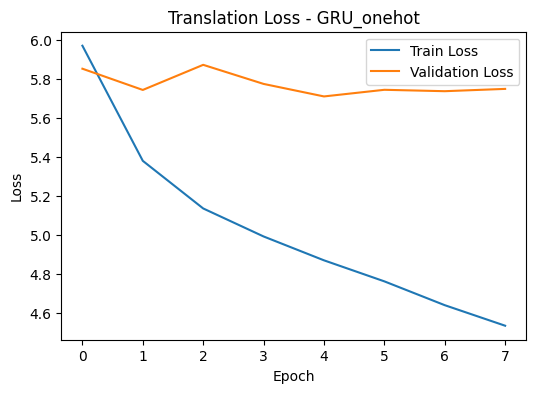

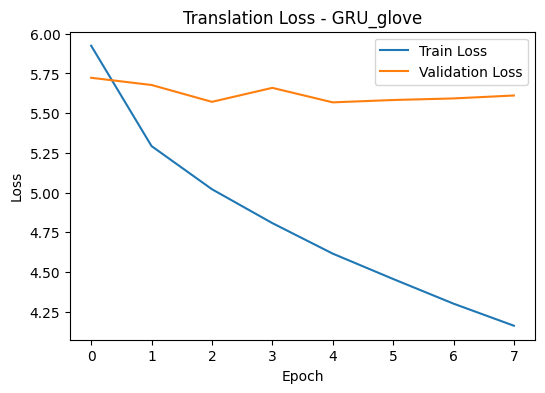

In [46]:
for name, res in translation_results.items():
    plt.figure(figsize=(6, 4))
    plt.plot(res["history"]["train_loss"], label="Train Loss")
    plt.plot(res["history"]["val_loss"], label="Validation Loss")
    plt.title(f"Translation Loss - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [47]:
final_results = {
    "task_1_text_generation": textgen_results,
    "task_2_machine_translation": translation_results
}

with open("results.json", "w") as f:
    json.dump(final_results, f, indent=2)

print("Saved results.json")

Saved results.json


In [48]:
print("=== TEXT GENERATION RESULTS ===")
display(tg_df)

print("\n=== TRANSLATION RESULTS ===")
display(mt_df)

=== TEXT GENERATION RESULTS ===


,Experiment,Test Loss,Test Perplexity,Sample Output
1,LSTM_glove,5.6891,295.61,"to be or not to be a <unk> , and <unk> , and <..."
0,LSTM_onehot,5.7696,320.41,"to be or not to be <unk> 'd , and <unk> 'd , a..."



=== TRANSLATION RESULTS ===


,Experiment,Test Loss,BLEU Score,Sample Prediction
1,GRU_glove,5.6417,7.47,"a las <unk> de <unk> no <unk> <unk> , <unk> , ..."
0,GRU_onehot,5.7791,5.89,"el <unk> de la <unk> , <unk> , <unk> , <unk> ,..."
